In [1]:
import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.time import Time
import socolors

from latcom.utils import yield_utils as yd
from latcom.utils.parsing import parse_dict

from latcom.utils.optical_loading import pwv_interp

%load_ext autoreload
%autoreload 2

In [2]:
with open("../../nets/nets_07142026.pk", "rb") as f:
    net_dict = pk.load(f)


c_base = "C0"
c_goal = "C3"

In [3]:
# df_yield = yd.parse_yield(net_dict=net_dict)
df_yield = parse_dict(net_dict=net_dict)
toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [4]:
# with open("../data/yields.pk", "wb") as f:
#    pk.dump(df_yield, f)

In [5]:
t_cut_low = Time("2026-06-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-08-01T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df_yield.labels)
weighted_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df_yield.where(
        (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 1 / np.sin(np.deg2rad(50)))
        & (df_yield.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df_yield.t_obs)
        & (df_yield.labels == label)
    ).yields
    weighted_means[i] = np.mean(data)
means_df = pd.DataFrame({"labels": set_labels, "yields": weighted_means})

In [6]:
means_df.loc[means_df.labels == "090_mv24"]

,labels,yields
6,090_mv24,0.819407


In [7]:
np.mean(means_df.yields)

np.float64(0.653452972371538)

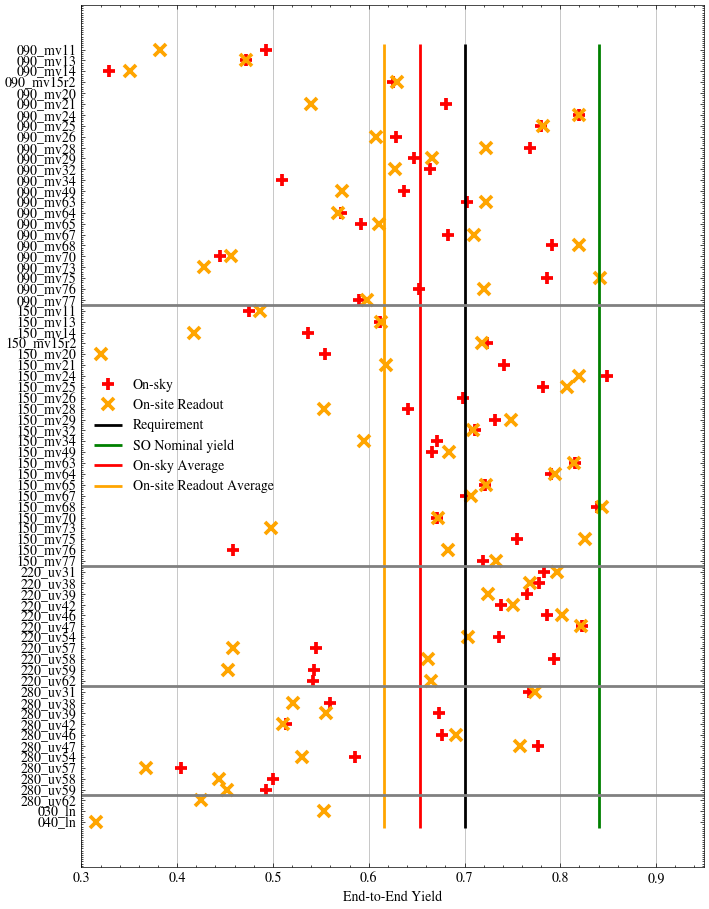

In [8]:
plt.style.use("apj-fullwidth")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 9))

# sns.boxplot(data=df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 3 / np.sin(np.deg2rad(50))),
#    x="yields", y="labels",
# )

sns.pointplot(
    data=means_df,
    x="yields",
    y="labels",
    label="On-sky",
    marker="+",
    linestyle="none",
    color="red",
)


sns.pointplot(
    data=toby_df,
    x="yields",
    y="labels",
    linestyle="none",
    marker="x",
    color="orange",
    zorder=2,
    label="On-site Readout",
)
"""
sns.pointplot(
    data=ptown_df,
    x="yields",
    y="labels",
    linestyle="none",
    marker="+",
    color="0.05",
    zorder=2,
    label="PTown Dark",
)
"""
plt.xlim(0.3, 0.95)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(0.7, ymin=ymin, ymax=ymax, label="Requirement", color="black")
plt.vlines(0.84, ymin=ymin, ymax=ymax, label="SO Nominal yield", color="green")

# plt.vlines(np.nanmean(df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 1 / np.sin(np.deg2rad(50))).yields),
#    ymin=ymin, ymax=ymax, label="On-Sky Average", color="black",
# )
plt.vlines(
    np.nanmean(means_df.yields),
    ymin=ymin,
    ymax=ymax,
    label="On-sky Average",
    color="red",
)
plt.vlines(
    np.nanmean(toby_df.yields),
    ymin=ymin,
    ymax=ymax,
    label="On-site Readout Average",
    color="orange",
)


pos_090 = (
    len([label for label in set(df_yield.labels.to_numpy()) if "090" in label]) - 0.5
)
pos_150 = pos_090 + len(
    [label for label in set(df_yield.labels.to_numpy()) if "150" in label]
)
pos_220 = pos_150 + len(
    [label for label in set(df_yield.labels.to_numpy()) if "220" in label]
)
pos_280 = pos_220 + len(
    [label for label in set(df_yield.labels.to_numpy()) if "280" in label]
)

plt.hlines([pos_090, pos_150, pos_220, pos_280], xmin=xmin, xmax=xmax, color="0.5")

plt.legend()

ax.xaxis.grid(True)
ax.set(xlabel="End-to-End Yield", ylabel="")

plt.savefig("../../plts/aso_yield.png", dpi=600, bbox_inches="tight")
plt.savefig("../../plts/aso_yield.pdf", dpi=600, bbox_inches="tight")

# Daily yields

In [107]:
import astropy.units as u
import matplotlib.dates as mdates
from pathlib import Path
import datetime as dt

pwv = pwv_interp()

t0 = Time("2026-04-26T00:00:00", format="isot", scale="utc")
tf = Time("2026-07-04T00:00:00", format="isot", scale="utc")
ndays = int(((tf-t0)/u.day).value)
days = np.linspace(t0, tf, ndays)

In [103]:
daily_yields = {label:np.zeros(len(days)) for label in set_labels}
daily_yields["total_yield"] = np.zeros(len(days))
daily_yields["pwv"] = np.zeros(len(days))

for i, day in enumerate(days):
    cur_yields = np.zeros(len(set_labels))
    for j, label in enumerate(set_labels):
        data = df_yield.where(
            (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 1 / np.sin(np.deg2rad(50)))
            & (df_yield.t_obs < (day + 1*u.day).unix)
            & (day.unix < df_yield.t_obs)
            & (df_yield.labels == label)
        ).yields
        mean_data = np.nanmean(data)
        cur_yields[j] = mean_data
        daily_yields[label][i] = mean_data
    hours = np.linspace(day, day + 1*u.day, 24)
    pwvs = np.zeros(len(hours))
    for j, hour in enumerate(hours):
        pwvs[j] = pwv(hour.unix)
    daily_yields["pwv"][i] = np.nanmean(pwvs)
    daily_yields["total_yield"][i] = np.nanmean(cur_yields)

/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:1

In [108]:
times = [dt.datetime.fromtimestamp(day.unix) for day in days]

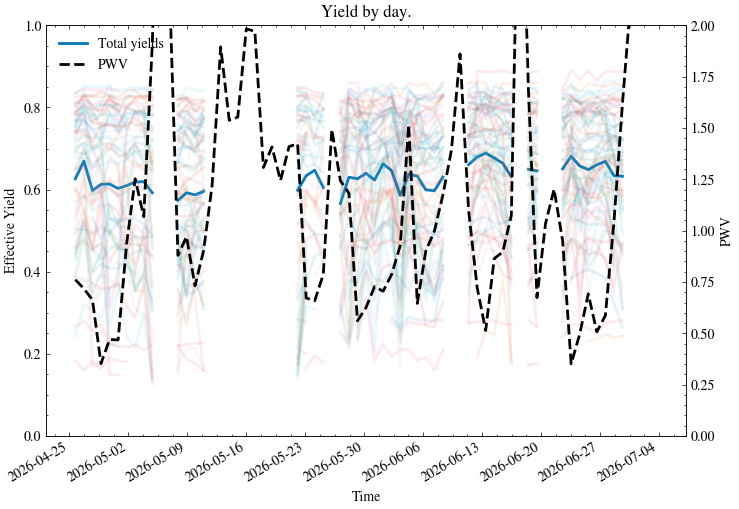

In [114]:
fig, ax = plt.subplots()
lns = []

total = ax.plot(times, daily_yields["total_yield"], label="Total yields")
for key in daily_yields:
    if key == "total_yields" or key == "pwv": continue
    ax.plot(times, daily_yields[key], label=key, alpha = 0.1)

ax2 = ax.twinx()
pw = ax2.plot(times, daily_yields["pwv"], label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Effective Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gcf().autofmt_xdate()

lns = lns + total + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield by day.")
output_dir = Path(f"../../plts/yields/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"daily_yields.pdf", dpi=600)
plt.savefig(output_dir / f"daily_yields.png", dpi=600)

plt.show()